In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec  
import warnings
from cmcrameri import cm

In [2]:
import babet as bb
import atmicp

In [3]:
ml_to_pl = pd.read_csv('../ml_to_pl.csv', index_col=0)
pl = list(ml_to_pl['pf [hPa]'].values[1:]) # pressure levels corresponding to model level, ascending

In [4]:
t_delta = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/t_6_delta_ERA5_1979-2021.nc')
q_delta = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/q_6_delta_ERA5_1979-2021.nc')
d_delta = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/d_6_delta_ERA5_1979-2021.nc')
vo_delta = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/vo_6_delta_ERA5_1979-2021.nc')

/tmp/user/27529/ipykernel_3707079/3268406276.py:1: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  t_delta = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/t_6_delta_ERA5_1979-2021.nc')
/tmp/user/27529/ipykernel_3707079/3268406276.py:3: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta6

In [5]:
vo_delta

<xarray.Dataset> Size: 4GB
Dimensions:     (hybrid: 137, latitude: 1280, longitude: 2560)
Coordinates:
  * hybrid      (hybrid) float64 1kB 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
  * latitude    (latitude) float64 10kB 89.89 89.75 89.61 ... -89.75 -89.89
  * longitude   (longitude) float64 20kB 0.0 0.1406 0.2812 ... 359.6 359.7 359.9
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    t           (hybrid, latitude, longitude) float64 4GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-15T16:00 GRIB to CDM+CF via cfgrib-0.9.1...

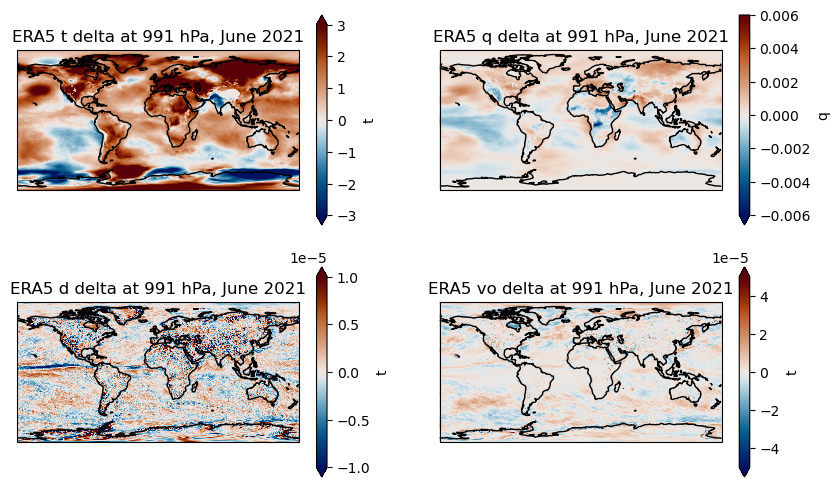

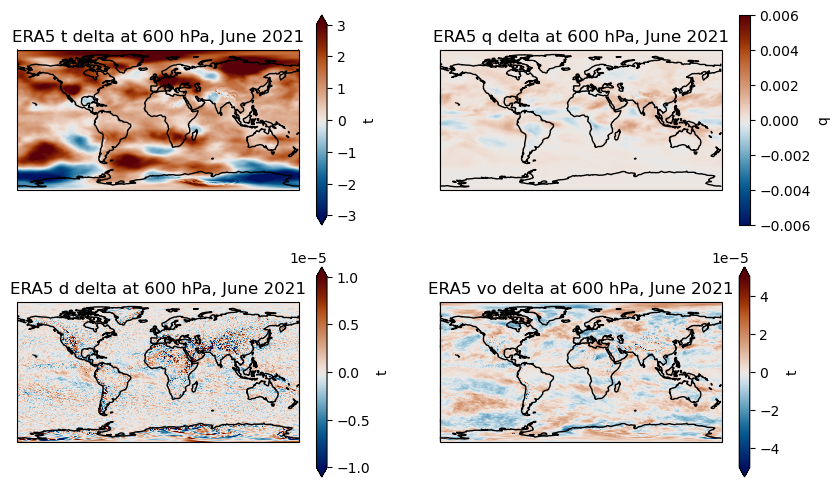

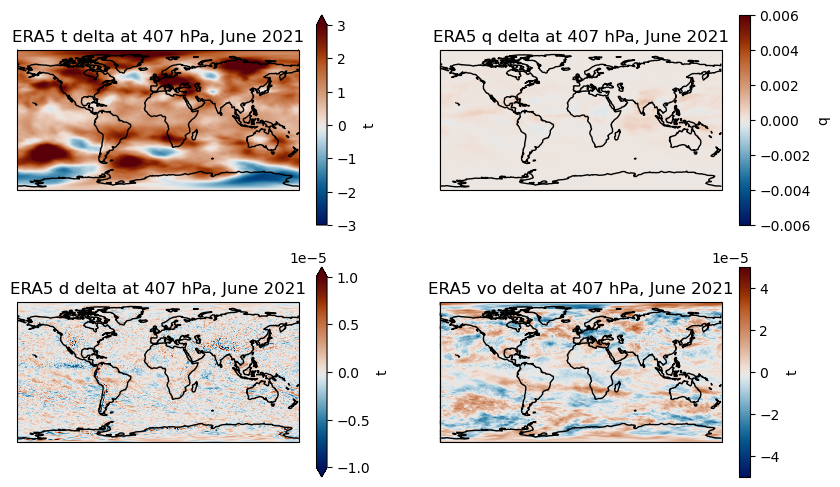

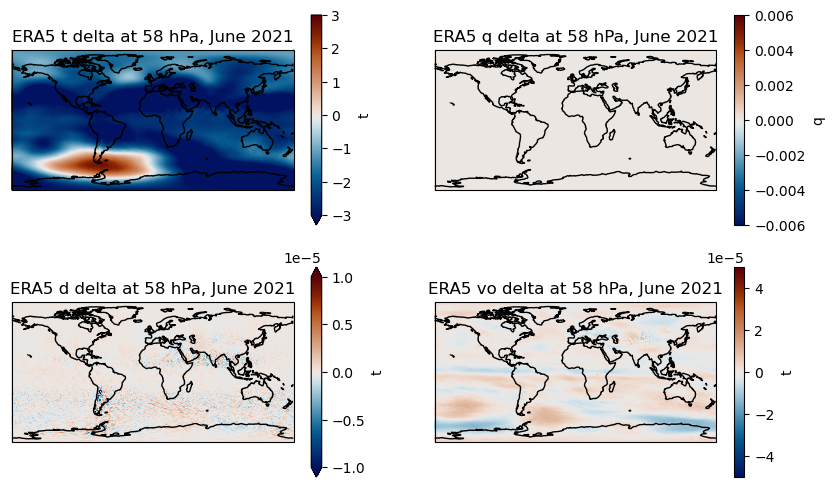

In [15]:

for level in [130, 100, 90, 50]:
    fig, ax = plt.subplots(2,2, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    plev = int(np.round(ml_to_pl.loc[level, 'ph [hPa]']))

    vmax = 3
    t_delta.t.sel(hybrid=level).plot(ax=ax[0,0], vmin=-vmax, vmax=vmax, cmap=cm.vik)
    ax[0,0].coastlines()
    ax[0,0].set_title(f'ERA5 t delta at {plev} hPa, June 2021')

    vmax = 0.006
    q_delta.q.sel(level=level).plot(ax=ax[0,1], vmin=-vmax, vmax=vmax, cmap=cm.vik)
    ax[0,1].coastlines()
    ax[0,1].set_title(f'ERA5 q delta at {plev} hPa, June 2021')

    vmax = 1e-5
    d_delta.t.sel(hybrid=level).plot(ax=ax[1,0], vmin=-vmax, vmax=vmax, cmap=cm.vik)
    ax[1,0].coastlines()
    ax[1,0].set_title(f'ERA5 d delta at {plev} hPa, June 2021')

    vmax = 5e-5
    vo_delta.t.sel(hybrid=level).plot(ax=ax[1,1], vmin=-vmax, vmax=vmax, cmap=cm.vik)
    ax[1,1].coastlines()
    ax[1,1].set_title(f'ERA5 vo delta at {plev} hPa, June 2021')

    plt.show()


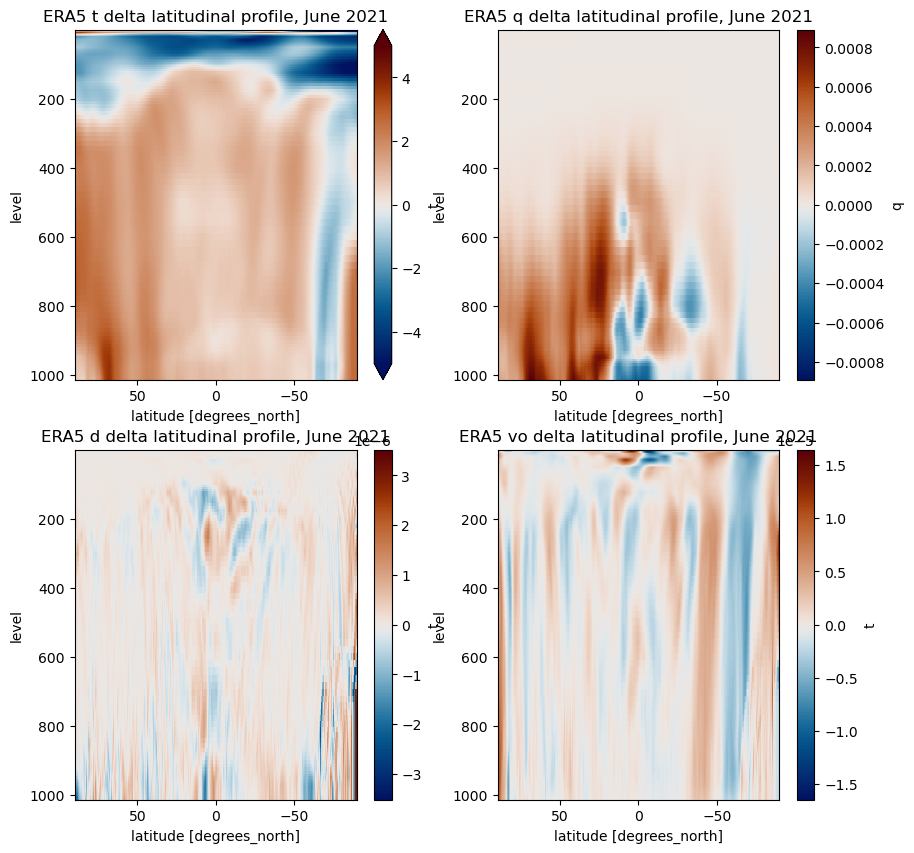

In [46]:
# latitudinal profile of deltas
p = ml_to_pl["ph [hPa]"].values[1:]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))

t = t_delta.mean("longitude").squeeze()["t"]
t_profile = (t.assign_coords(level=("hybrid", p)).swap_dims({"hybrid": "level"}))
qm = t_profile.plot(x='latitude', y='level', cmap=cm.vik, vmin=-5, vmax=5, ax=ax[0, 0])
ax[0, 0].set_title('ERA5 t delta latitudinal profile, June 2021')
ax[0, 0].invert_xaxis()
ax[0, 0].invert_yaxis()

q = q_delta.mean("longitude").squeeze()["q"]
q_profile = (q.assign_coords(level=("level", p)).swap_dims({"level": "level"}))
qm = q_profile.plot(x='latitude', y='level', cmap=cm.vik, ax=ax[0, 1])
ax[0, 1].set_title('ERA5 q delta latitudinal profile, June 2021')
ax[0, 1].invert_xaxis() 
ax[0, 1].invert_yaxis()

d = d_delta.mean("longitude").squeeze()["t"]
d_profile = (d.assign_coords(level=("hybrid", p)).swap_dims({"hybrid": "level"}))
qm = d_profile.plot(x='latitude', y='level', cmap=cm.vik, ax=ax[1, 0])
ax[1, 0].set_title('ERA5 d delta latitudinal profile, June 2021')
ax[1, 0].invert_xaxis()
ax[1, 0].invert_yaxis()

vo = vo_delta.mean("longitude").squeeze()["t"]
vo_profile = (vo.assign_coords(level=("hybrid", p)).swap_dims({"hybrid": "level"}))
qm = vo_profile.plot(x='latitude', y='level', cmap= cm.vik, ax=ax[1, 1])
ax[1, 1].set_title('ERA5 vo delta latitudinal profile, June 2021')
ax[1, 1].invert_xaxis()
ax[1, 1].invert_yaxis() 


In [11]:
# TODO!!
def q_to_tcwv(q, p, model_level=True):
    # Convert specific humidity (q) to total column water vapor (TCWV)
    # TCWV = q * g * p / (R * T)
    # where g is the acceleration due to gravity, p is the pressure, R is the specific gas constant for dry air, and T is the temperature.
    
    if model_level: 
        # Convert q from model level to pressure level
        t = 1

    g = 9.81  # m/s^2
    R = 287.05  # J/(kg*K)
    
    # Assuming a standard atmosphere, we can use a reference pressure and temperature
    p_ref = 101325  # Pa
    T_ref = 288.15  # K
    
    tcwv = q * g * p_ref / (R * T_ref)
    
    return tcwv

In [ ]:
test = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/test_ATMICP/TEMPBLOB_IC/temperature_blob_model_grid.grb2')
test

In [4]:
test = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/DATA/postproc/deltas/aux/t_ref.grb2')
test

ecCodes provides no latitudes/longitudes for gridType='sh'


<xarray.Dataset> Size: 225MB
Dimensions:     (hybrid: 137, values: 410240)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
  * hybrid      (hybrid) float64 1kB 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    t           (hybrid, values) float32 225MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-16T12:15 GRIB to CDM+CF via cfgrib-0.9.1...